In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
ruta_fits = 'BlazEr1_catalog.fits'

In [2]:
with fits.open(ruta_fits) as arc:
    print("Estructura de BlazEr1")
    arc.info() #Info general del archivo, este es solo para ver su estructura general


"""
El error se produce debido a las unidades sigma y nanomagg. 

"""
tabla_astropy = Table.read(ruta_fits, hdu=1)
df = tabla_astropy.to_pandas()
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Ahora, para listar todas las columnas de corrido:
print(df.columns.tolist())


Estructura de BlazEr1
Filename: BlazEr1_catalog.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       6   ()      
  1  BLAZER1       1 BinTableHDU   2379   5865R x 661C   [29A, D, D, 5A, D, 32A, 15A, 21A, 20A, 26A, 29A, 28A, 14A, 17A, D, 32A, 23A, J, J, K, K, J, D, 1PE(2), D, 1PE(2), D, D, D, D, D, D, D, D, E, E, E, E, E, 1PE(2), E, E, E, E, 1PE(2), E, E, 1PE(2), E, E, 1PE(2), E, E, E, J, E, E, E, E, E, E, E, 1PE(2), E, E, 1PE(2), E, E, 1PE(2), E, E, E, J, E, E, E, E, E, E, E, 1PE(2), E, E, 1PE(2), E, E, 1PE(2), E, E, E, J, E, E, E, E, E, E, E, 1PE(2), E, E, 1PE(2), E, E, 1PE(2), E, E, E, J, E, E, E, E, E, E, E, 1PE(2), E, E, 1PE(2), E, E, 1PE(2), E, E, E, J, E, E, E, E, E, E, E, 1PE(2), E, E, 1PE(2), E, E, 1PE(2), E, E, E, J, E, E, E, E, E, E, E, 1PE(2), E, E, 1PE(2), E, E, 1PE(2), E, E, E, J, E, E, E, E, E, E, E, 1PE(2), E, E, 1PE(2), E, E, 1PE(2), E, E, E, J, E, E, E, E, E, E, E, 1PE(2), E, E, 1PE(2), E, E, 1PE(2), E, E, E, J, E, E

['SRC_NAME', 'RAJ2000', 'DECJ2000', 'BLAZAR_CLASS', 'CONF_BLAZAR', 'FGL_SRC_NAME', 'BZCAT_SRC_NAME', 'HSP_SRC_NAME', 'HIGHZ_SRC_NAME', 'MILLIQUAS_SRC_NAME', 'KDEBLLACS_SRC_NAME', 'WIBRALS2_SRC_NAME', 'ABC_SRC_NAME', 'BROS_SRC_NAME', 'ANGSEP', 'DETUID', 'IAUNAME', 'SKYTILE', 'ID_SRC', 'UID', 'UID_HARD', 'ID_CLUSTER', 'RA', 'RA_ERR', 'DEC', 'DEC_ERR', 'RA_RAW', 'DEC_RAW', 'POS_ERR', 'RADEC_ERR', 'LII', 'BII', 'ELON', 'ELAT', 'MJD', 'MJD_MIN', 'MJD_MAX', 'EXT', 'EXT_ERR', 'EXT_ASYM_ERR', 'EXT_LIKE', 'DET_LIKE_0', 'ML_CTS_1', 'ML_CTS_1_ERR', 'ML_CTS_1_ASYM_ERR', 'ML_RATE_1', 'ML_RATE_1_ERR', 'ML_RATE_1_ASYM_ERR', 'ML_FLUX_1', 'ML_FLUX_1_ERR', 'ML_FLUX_1_ASYM_ERR', 'ML_BKG_1', 'ML_EXP_1', 'ML_EEF_1', 'APE_CTS_1', 'APE_BKG_1', 'APE_EXP_1', 'APE_RADIUS_1', 'APE_POIS_1', 'DET_LIKE_P1', 'ML_CTS_P1', 'ML_CTS_P1_ERR', 'ML_CTS_P1_ASYM_ERR', 'ML_RATE_P1', 'ML_RATE_P1_ERR', 'ML_RATE_P1_ASYM_ERR', 'ML_FLUX_P1', 'ML_FLUX_P1_ERR', 'ML_FLUX_P1_ASYM_ERR', 'ML_BKG_P1', 'ML_EXP_P1', 'ML_EEF_P1', 'APE_CTS_P

In [3]:
df['BLAZAR_CLASS'].unique()


array([b'bcu  ', b'bll  ', b'fsrq ', b'bzg  ', b'bllc ', b'fsrqc',
       b'bcuc '], dtype=object)

In [4]:

columnas = ['BLAZAR_CLASS', 'FGL_SRC_NAME' ,'FGL_PL_INDEX', 'FGL_PL_INDEX_ERR', 'FREE_GAMMA', 'FREE_GAMMA_ERR', 'ML_CTS_1']
cambio_nom = {
    b'bcu  ' : 'BZU',
    b'bll  ' : 'BZB',
    b'fsrq ' : 'BZQ',
    b'bzg  ' : 'BZG',
} 

df_muestra = df[columnas].copy()
df_muestra['BLAZAR_CLASS'] = df_muestra['BLAZAR_CLASS'].replace(cambio_nom) #Esto está aquí para cambiar el nombre de los blázares a la notación del grupo
df_muestra = df_muestra[df_muestra['FREE_GAMMA'].notna()] #Descarta los Free Gamma que poseen NaN
df_muestra = df_muestra[df_muestra['FREE_GAMMA_ERR'].notna()]
df_muestra = df_muestra[df_muestra['FGL_PL_INDEX'].notna()] #Descarta los Gamma gamma que poseen NaN
df_muestra = df_muestra[df_muestra['FGL_PL_INDEX_ERR'].notna()]
df_muestra = df_muestra[df_muestra['FGL_SRC_NAME'].notna()] #Descarta los blazares que no coinciden con eROSITA o están vacíos
df_muestra = df_muestra[df_muestra['FGL_SRC_NAME'] != '']
df_muestra = df_muestra[df_muestra['ML_CTS_1'] > 50] #Esto es para quitar las mediciones de eROSITA menores a 50 counts
print("Dimensiones de la muestra:", df_muestra.shape)
df_muestra.head()

Dimensiones de la muestra: (583, 7)


,BLAZAR_CLASS,FGL_SRC_NAME,FGL_PL_INDEX,FGL_PL_INDEX_ERR,FREE_GAMMA,FREE_GAMMA_ERR,ML_CTS_1
0,BZU,b'4FGL_J0001.6-4156 ',1.781085,0.063962,2.399167,"[-0.17117156, 0.20507514]",640.261597
1,BZU,b'4FGL_J0003.1-5248 ',1.781021,0.066147,2.501480,"[-0.23354085, 0.27093565]",343.812500
9,BZU,b'4FGL_J0032.5-4724 ',1.694125,0.163683,3.082444,"[-0.42883846, 0.58605003]",83.560867
12,BZU,b'4FGL_J0049.5-4150 ',2.057240,0.157466,3.401565,"[-0.5567421, 0.55221]",68.427818
13,BZU,b'4FGL_J0050.8-3428 ',1.945315,0.215441,2.275134,"[-0.3946951, 0.53194326]",90.257187


In [5]:
#Guardar muestra en un archivo fits y CSV
df_filtrado = df_muestra[
    (df_muestra['BLAZAR_CLASS'] != 'BZU') & 
    (df_muestra['BLAZAR_CLASS'] != 'BZG')
].copy()

df_filtrado = df_filtrado.reset_index(drop=True)
df_filtrado.to_csv('catalogo_muestra.csv', index=False)
tabla_m = Table.from_pandas(df_filtrado)
tabla_m.write('catalogo_muestra.fits', format='fits', overwrite=True)

print('Catálogo exportado exitosamente tanto en FITS como en CSV')




Catálogo exportado exitosamente tanto en FITS como en CSV


In [6]:
BZQ = df_muestra['BLAZAR_CLASS'] ==  'BZQ'
df_2 = df_muestra[BZQ].copy()
df_2.head() #Muestra de BZQ

,BLAZAR_CLASS,FGL_SRC_NAME,FGL_PL_INDEX,FGL_PL_INDEX_ERR,FREE_GAMMA,FREE_GAMMA_ERR,ML_CTS_1
955,BZQ,b'4FGL_J0023.7-6820 ',2.829112,0.064780,1.961880,"[-0.30787045, 0.4182908]",126.018112
959,BZQ,b'4FGL_J0049.6-4500 ',2.689648,0.105093,2.188238,"[-0.34902146, 0.45816147]",108.394104
960,BZQ,b'4FGL_J0050.0-5736 ',2.434874,0.028503,1.576191,"[-0.31256285, 0.32192817]",116.782669
964,BZQ,b'4FGL_J0112.0-6634 ',2.725361,0.063922,1.797399,"[-0.32978338, 0.3730594]",123.991753
968,BZQ,b'4FGL_J0126.0-2221 ',2.529519,0.072036,1.725797,"[-0.39548314, 0.5012269]",77.557808


In [7]:
BZB = df_muestra['BLAZAR_CLASS'] == 'BZB'
df_1 = df_muestra[BZB].copy()
df_1.head() #Muestra de BZB

,BLAZAR_CLASS,FGL_SRC_NAME,FGL_PL_INDEX,FGL_PL_INDEX_ERR,FREE_GAMMA,FREE_GAMMA_ERR,ML_CTS_1
426,BZB,b'4FGL_J0002.1-6728 ',1.817964,0.070351,2.481154,"[-0.2488324, 0.36289087]",212.126968
427,BZB,b'4FGL_J0009.8-4317 ',2.124825,0.081628,3.025977,"[-0.4400523, 0.6614622]",72.716385
429,BZB,b'4FGL_J0014.1-5022 ',2.107366,0.081496,2.361000,"[-0.24691767, 0.29059595]",296.279785
431,BZB,b'4FGL_J0021.9-5140 ',2.018452,0.045290,2.604091,"[-0.3374154, 0.39249557]",165.242355
432,BZB,b'4FGL_J0026.6-4600 ',1.997174,0.089169,2.607424,"[-0.27657703, 0.3904862]",152.958679


In [8]:
print("El número total de BZB es ", df_1.shape[0])
print("El número total de BZQ es ", df_2.shape[0])
print("El número total de Blazares (BZQ y BZB) es ", df_1.shape[0] + df_2.shape[0])

El número total de BZB es  332
El número total de BZQ es  120
El número total de Blazares (BZQ y BZB) es  452


## Histogramas 

<>:12: SyntaxWarning: invalid escape sequence '\G'
<>:12: SyntaxWarning: invalid escape sequence '\G'
C:\Users\jaosi\AppData\Local\Temp\ipykernel_14508\2116620530.py:12: SyntaxWarning: invalid escape sequence '\G'
  plt.xlabel(f'$\Gamma_x$')


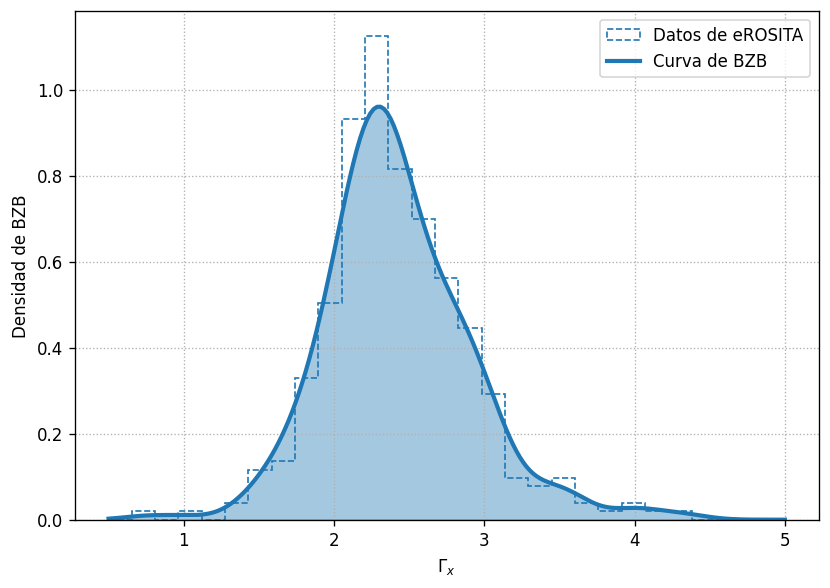

In [11]:
from scipy.stats import gaussian_kde
fig, ax = plt.subplots(figsize=(8, 5.5), dpi=120)
inter = np.linspace(0.5, 5, 30)
plt.hist(df_1['FREE_GAMMA'], bins = inter,density = True, histtype='step', linestyle = '--', color='#1f77b4',alpha=1, label='Datos de eROSITA')
x1_curv = np.linspace(0.5,5,200)
kernel1 = gaussian_kde(df_1['FREE_GAMMA'])
y1_curv = kernel1(x1_curv)
plt.plot(x1_curv, y1_curv,color='#1f77b4', lw=2.5, label='Curva de BZB')
plt.fill_between(x1_curv, y1_curv, 0, color='#1f77b4', alpha=0.4)
#plt.title(f'Histograma de BZB (eROSITA)')
plt.ylabel('Densidad de BZB')
plt.xlabel(f'$\Gamma_x$')
plt.grid(True, linestyle = ':')
plt.legend()
plt.savefig('BZBEROSITA.pdf')

<>:11: SyntaxWarning: invalid escape sequence '\G'
<>:11: SyntaxWarning: invalid escape sequence '\G'
C:\Users\jaosi\AppData\Local\Temp\ipykernel_14508\1357181126.py:11: SyntaxWarning: invalid escape sequence '\G'
  plt.xlabel(f'$\Gamma_x$')


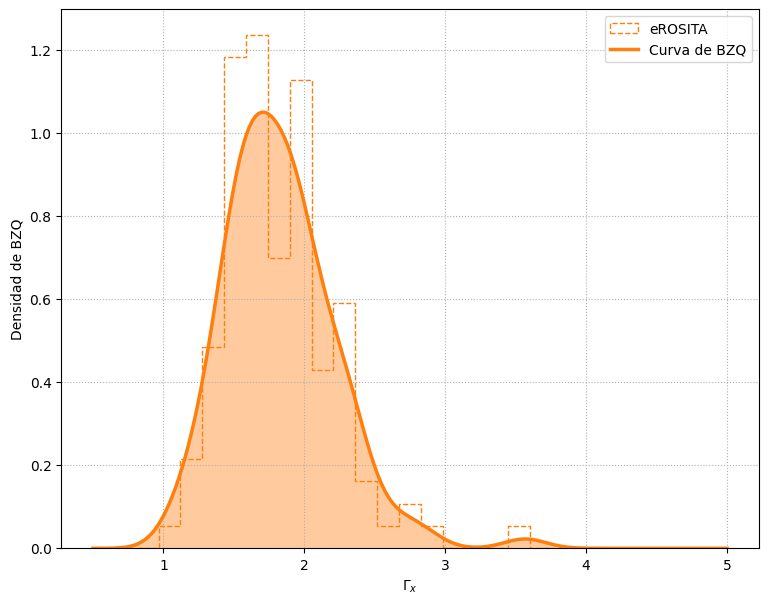

In [16]:
plt.figure(figsize = (9,7))
inter = np.linspace(0.5, 5, 30)
plt.hist(df_2['FREE_GAMMA'], bins = inter, density = True,histtype='step',  linestyle = '--',color='#ff7f0e',alpha=1, label='eROSITA')
x2_curv = np.linspace(0.5,5,200)
kernel2 = gaussian_kde(df_2['FREE_GAMMA'])
y2_curv = kernel2(x2_curv)
plt.plot(x2_curv, y2_curv,color='#ff7f0e', lw=2.5, label='Curva de BZQ')
plt.fill_between(x2_curv, y2_curv, 0, color='#ff7f0e', alpha=0.4)
#plt.title(f'Histograma de BZQ (eROSITA)')
plt.ylabel('Densidad de BZQ')
plt.xlabel(f'$\Gamma_x$')
plt.grid(True, linestyle = ':')
plt.legend()
plt.savefig('BZQEROSITA.pdf')

<>:11: SyntaxWarning: invalid escape sequence '\G'
<>:11: SyntaxWarning: invalid escape sequence '\G'
C:\Users\jaosi\AppData\Local\Temp\ipykernel_14508\2686325224.py:11: SyntaxWarning: invalid escape sequence '\G'
  plt.xlabel(f'$\Gamma_x$')


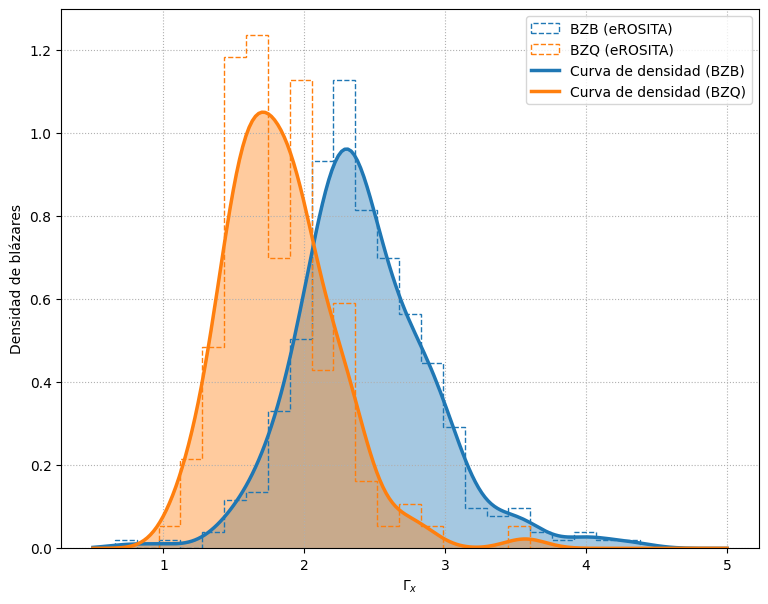

In [18]:
plt.figure(figsize = (9,7))
inter = np.linspace(0.5, 5, 30)
plt.hist(df_1['FREE_GAMMA'], bins = inter,density = True, histtype='step',  color='#1f77b4',alpha=1,linestyle = '--', label='BZB (eROSITA)')
plt.hist(df_2['FREE_GAMMA'], bins = inter, density = True,histtype='step',  color='#ff7f0e',alpha=1, linestyle = '--', label='BZQ (eROSITA)')

plt.plot(x1_curv, y1_curv,color='#1f77b4', lw=2.5, label='Curva de densidad (BZB)')
plt.plot(x2_curv, y2_curv,color='#ff7f0e', lw=2.5, label='Curva de densidad (BZQ)')
plt.fill_between(x1_curv, y1_curv, 0, color='#1f77b4', alpha=0.4)
plt.fill_between(x2_curv, y2_curv, 0, color='#ff7f0e', alpha=0.4)
plt.ylabel('Densidad de blázares')
plt.xlabel(f'$\Gamma_x$')
plt.legend()
plt.grid(True, linestyle = ':')
#plt.title('Histograma de BZB y BZQ (eROSITA)')
plt.savefig('BZEROSITA.pdf')
plt.show()

<>:10: SyntaxWarning: invalid escape sequence '\G'
<>:10: SyntaxWarning: invalid escape sequence '\G'
C:\Users\jaosi\AppData\Local\Temp\ipykernel_14508\3252793559.py:10: SyntaxWarning: invalid escape sequence '\G'
  plt.xlabel(f'$\Gamma_x$')


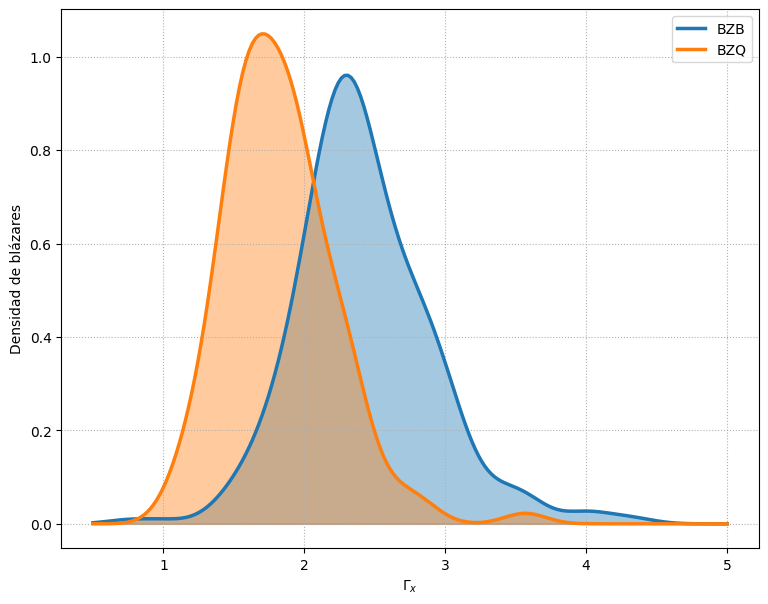

In [20]:
plt.figure(figsize = (9,7))
inter = np.linspace(0.5, 5, 30)

plt.plot(x1_curv, y1_curv,color='#1f77b4', lw=2.5, label='BZB')
plt.fill_between(x1_curv, y1_curv, 0, color='#1f77b4', alpha=0.4)
plt.plot(x2_curv, y2_curv,color='#ff7f0e', lw=2.5, label='BZQ')
plt.fill_between(x2_curv, y2_curv, 0, color='#ff7f0e', alpha=0.4)

plt.ylabel('Densidad de blázares')
plt.xlabel(f'$\Gamma_x$')
plt.legend()
plt.grid(True, linestyle = ':')
#plt.title('Histograma de BZB y BZQ (eROSITA)')
plt.savefig('BZgaussEROSITA.pdf')

<>:17: SyntaxWarning: invalid escape sequence '\G'
<>:17: SyntaxWarning: invalid escape sequence '\G'
C:\Users\jaosi\AppData\Local\Temp\ipykernel_14508\4138996069.py:17: SyntaxWarning: invalid escape sequence '\G'
  plt.xlabel(f'$\Gamma_\gamma$')


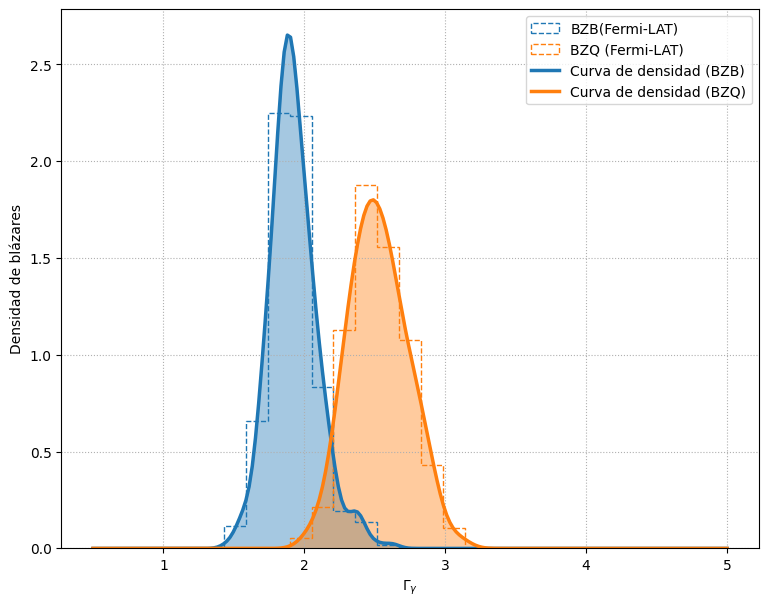

In [22]:
plt.figure(figsize = (9,7))
inter = np.linspace(0.5, 5, 30)
x1_curv = np.linspace(0.5,5,200)
kernel1 = gaussian_kde(df_1['FGL_PL_INDEX'])
y1_curv = kernel1(x1_curv)
x2_curv = np.linspace(0.5,5,200)
kernel2 = gaussian_kde(df_2['FGL_PL_INDEX'])
y2_curv = kernel2(x2_curv)

plt.hist(df_1['FGL_PL_INDEX'], bins = inter, histtype='step', linestyle = '--', density = True, color='#1f77b4',alpha=1, label='BZB(Fermi-LAT)')
plt.hist(df_2['FGL_PL_INDEX'], bins = inter, histtype='step', density = True,  linestyle = '--',color='#ff7f0e',alpha=1, label='BZQ (Fermi-LAT)')
plt.plot(x1_curv, y1_curv,color='#1f77b4', lw=2.5, label='Curva de densidad (BZB)')
plt.fill_between(x1_curv, y1_curv, 0, color='#1f77b4', alpha=0.4)
plt.plot(x2_curv, y2_curv,color='#ff7f0e', lw=2.5, label='Curva de densidad (BZQ)')
plt.fill_between(x2_curv, y2_curv, 0, color='#ff7f0e', alpha=0.4)
plt.ylabel(f'Densidad de blázares')
plt.xlabel(f'$\Gamma_\gamma$')
plt.legend()
plt.grid(True, linestyle = ':')
#plt.title('Histograma de BZB y BZQ (Fermi-LAT)')
plt.savefig('BZFERMI.pdf')
plt.show()

<>:15: SyntaxWarning: invalid escape sequence '\G'
<>:15: SyntaxWarning: invalid escape sequence '\G'
C:\Users\jaosi\AppData\Local\Temp\ipykernel_14508\3990243803.py:15: SyntaxWarning: invalid escape sequence '\G'
  plt.xlabel(f'$\Gamma_\gamma$')


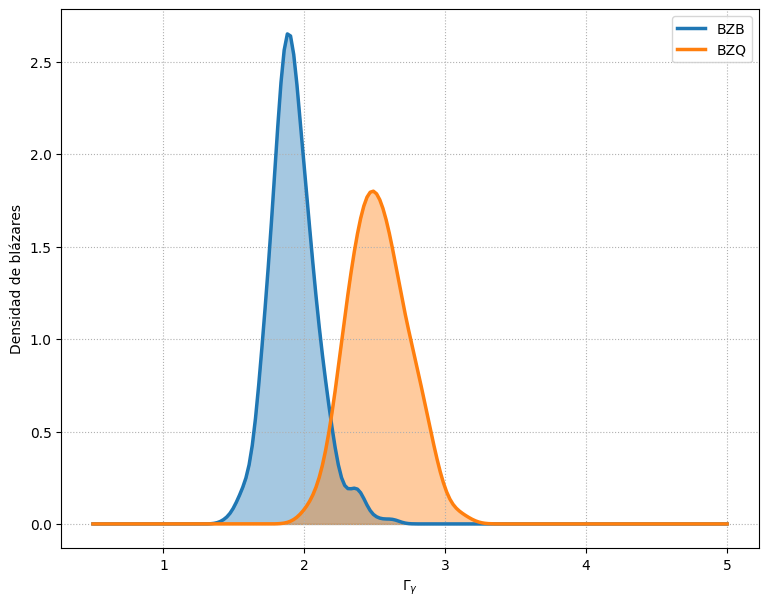

In [24]:
plt.figure(figsize = (9,7))
inter = np.linspace(0.5, 5, 30)
x1_curv = np.linspace(0.5,5,200)
kernel1 = gaussian_kde(df_1['FGL_PL_INDEX'])
y1_curv = kernel1(x1_curv)
x2_curv = np.linspace(0.5,5,200)
kernel2 = gaussian_kde(df_2['FGL_PL_INDEX'])
y2_curv = kernel2(x2_curv)

plt.plot(x1_curv, y1_curv,color='#1f77b4', lw=2.5, label='BZB')
plt.fill_between(x1_curv, y1_curv, 0, color='#1f77b4', alpha=0.4)
plt.plot(x2_curv, y2_curv,color='#ff7f0e', lw=2.5, label='BZQ')
plt.fill_between(x2_curv, y2_curv, 0, color='#ff7f0e', alpha=0.4)
plt.ylabel(f'Densidad de blázares')
plt.xlabel(f'$\Gamma_\gamma$')
plt.legend()
plt.grid(True, linestyle = ':')
#plt.title('Histograma de BZB y BZQ (Fermi-LAT)')
plt.savefig('BZgaussFERMI.pdf')
plt.show()

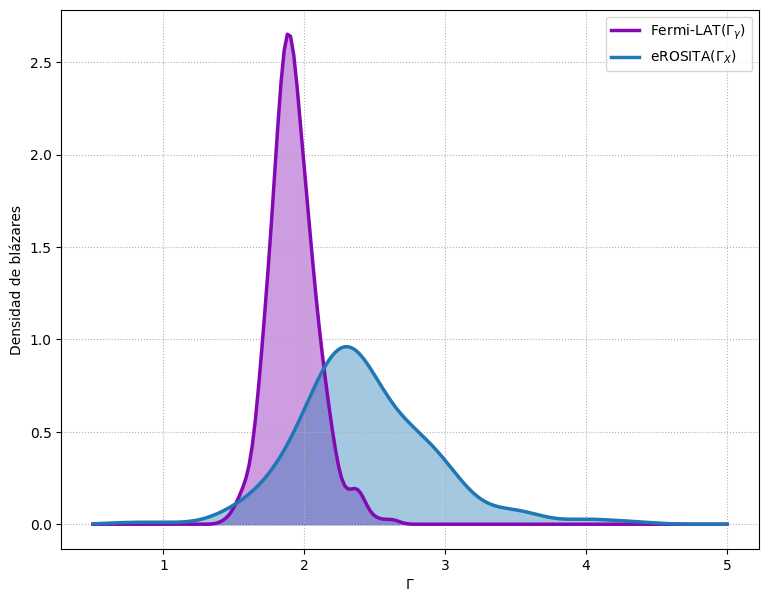

In [26]:
plt.figure(figsize = (9,7))
x_curv = np.linspace(0.5,5,200)
plt.plot(x_curv, gaussian_kde(df_1['FGL_PL_INDEX'])(x_curv),color="#8509b3", lw=2.5, label=r'Fermi-LAT($\Gamma_\gamma$)')
plt.fill_between(x_curv, gaussian_kde(df_1['FGL_PL_INDEX'])(x_curv), 0, color='#8509b3', alpha=0.4)
plt.plot(x_curv, gaussian_kde(df_1['FREE_GAMMA'])(x_curv),color='#1f77b4', lw=2.5, label=r'eROSITA($\Gamma_X$)')
plt.fill_between(x_curv, gaussian_kde(df_1['FREE_GAMMA'])(x_curv), 0, color='#1f77b4', alpha=0.4)


plt.ylabel(r'Densidad de blázares')
plt.xlabel(r'$\Gamma$')
plt.legend()
plt.grid(True, linestyle = ':')
#plt.title('Histograma de BZB')
plt.savefig('BZQHist.pdf')
plt.show()

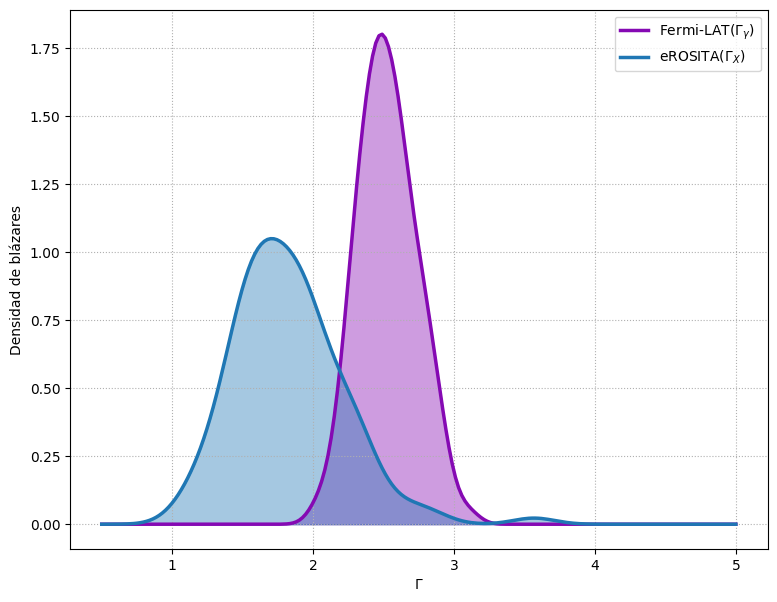

In [29]:
plt.figure(figsize = (9,7))
x_curv = np.linspace(0.5,5,200)
plt.plot(x_curv, gaussian_kde(df_2['FGL_PL_INDEX'])(x_curv),color="#8509b3", lw=2.5, label=r'Fermi-LAT($\Gamma_\gamma$)')
plt.fill_between(x_curv, gaussian_kde(df_2['FGL_PL_INDEX'])(x_curv), 0, color='#8509b3', alpha=0.4)
plt.plot(x_curv, gaussian_kde(df_2['FREE_GAMMA'])(x_curv),color='#1f77b4', lw=2.5, label=r'eROSITA($\Gamma_X$)')
plt.fill_between(x_curv, gaussian_kde(df_2['FREE_GAMMA'])(x_curv), 0, color='#1f77b4', alpha=0.4)


plt.ylabel(r'Densidad de blázares')
plt.xlabel(r'$\Gamma$')
plt.legend()
plt.grid(True, linestyle = ':')
#plt.title('Histograma de BZQ')
plt.savefig('BZQHist.pdf')
plt.show()

### Gráficas de dispersión y de violín

<>:4: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:4: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
C:\Users\jaosi\AppData\Local\Temp\ipykernel_22060\907002739.py:4: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel(f'$\log \Gamma_X$ (eROSITA)')
C:\Users\jaosi\AppData\Local\Temp\ipykernel_22060\907002739.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel(f'$\log \Gamma_\gamma$ (Fermi-LAT)')


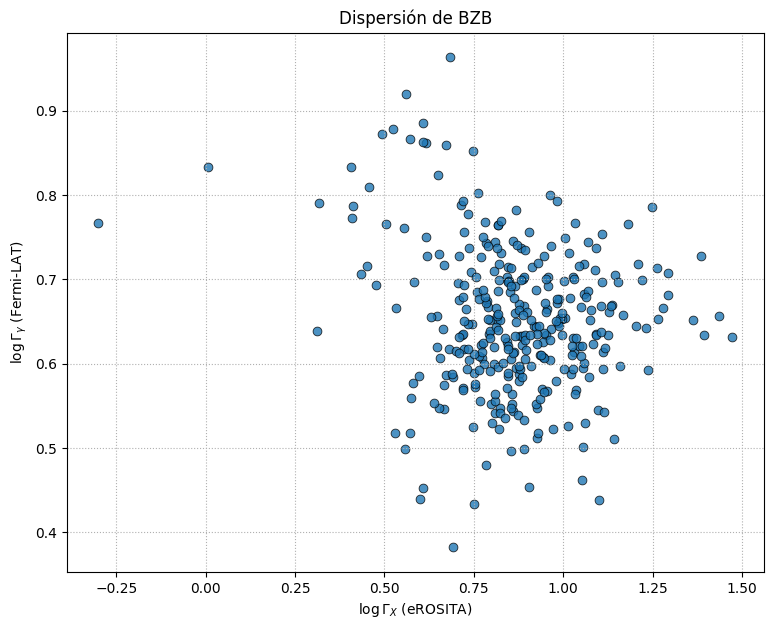

In [ ]:
plt.figure(figsize = (9,7))
plt.scatter(np.log(df_1['FREE_GAMMA']),np.log(df_1['FGL_PL_INDEX']), color='#1f77b4', alpha=0.8,edgecolors='k',linewidths=0.6, s=40,label='BZB')
plt.title('Dispersión de BZB')
plt.xlabel(f'$\log \Gamma_X$ (eROSITA)')
plt.ylabel(f'$\log \Gamma_\gamma$ (Fermi-LAT)')
plt.grid(True, linestyle = ':')

plt.show()

<>:4: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:4: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
C:\Users\jaosi\AppData\Local\Temp\ipykernel_22060\4172612958.py:4: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel(f'$\log \Gamma_X$ (eROSITA)')
C:\Users\jaosi\AppData\Local\Temp\ipykernel_22060\4172612958.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel(f'$\log \Gamma_\gamma$ (Fermi-LAT)')


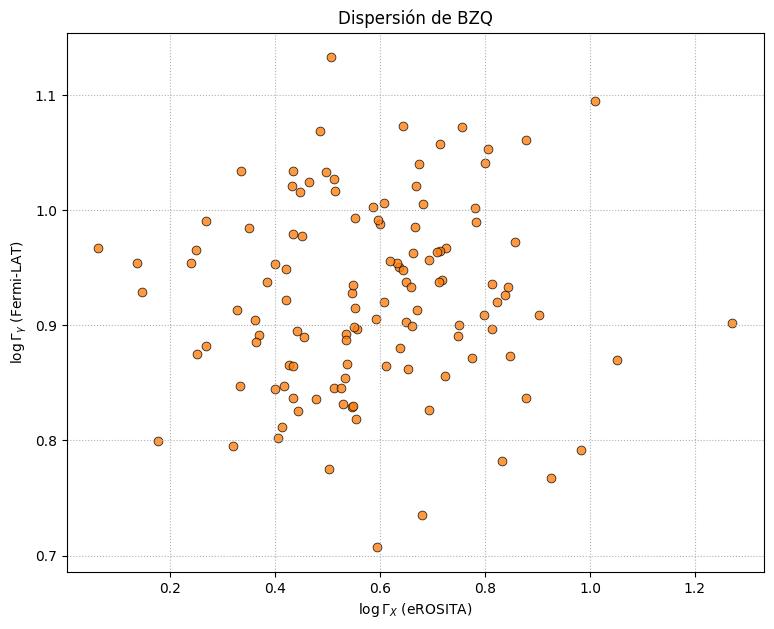

In [18]:
plt.figure(figsize = (9,7))
plt.scatter(np.log(df_2['FREE_GAMMA']),np.log(df_2['FGL_PL_INDEX']), color='#ff7f0e', alpha=0.8,edgecolors='k',linewidths=0.6, s=40,label='BZQ')
plt.title('Dispersión de BZQ')
plt.xlabel(f'$\log \Gamma_X$ (eROSITA)')
plt.ylabel(f'$\log \Gamma_\gamma$ (Fermi-LAT)')
plt.grid(True, linestyle = ':')
plt.show()

<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
<>:5: SyntaxWarning: invalid escape sequence '\l'
<>:6: SyntaxWarning: invalid escape sequence '\l'
C:\Users\jaosi\AppData\Local\Temp\ipykernel_22060\2356730810.py:5: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel(f'$\log \Gamma_X$ (eROSITA)')
C:\Users\jaosi\AppData\Local\Temp\ipykernel_22060\2356730810.py:6: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel(f'$\log \Gamma_\gamma$ (Fermi-LAT)')


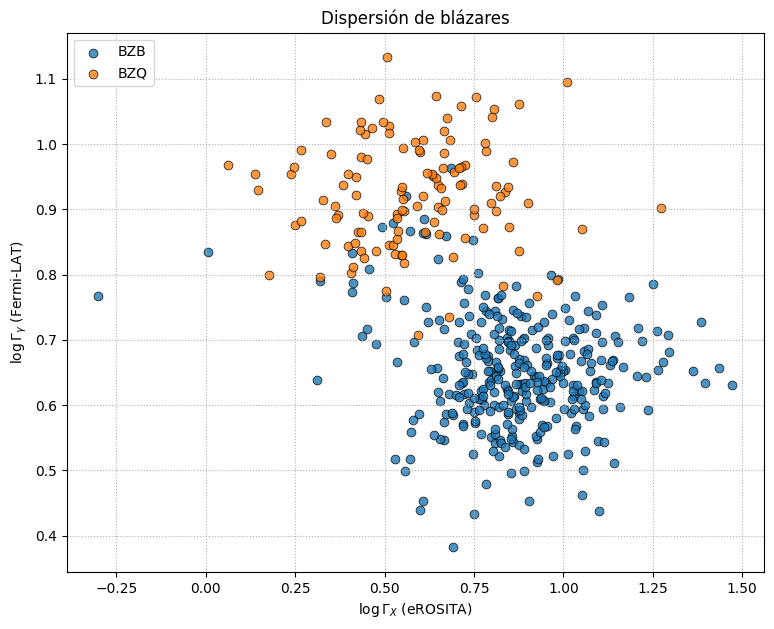

In [19]:
plt.figure(figsize = (9,7))
plt.scatter(np.log(df_1['FREE_GAMMA']),np.log(df_1['FGL_PL_INDEX']), color='#1f77b4', alpha=0.8,edgecolors='k',linewidths=0.6, s=40,label='BZB')
plt.scatter(np.log(df_2['FREE_GAMMA']),np.log(df_2['FGL_PL_INDEX']), color='#ff7f0e', alpha=0.8,edgecolors='k',linewidths=0.6, s=40,label='BZQ')
plt.title('Dispersión de blázares')
plt.xlabel(f'$\log \Gamma_X$ (eROSITA)')
plt.ylabel(f'$\log \Gamma_\gamma$ (Fermi-LAT)')
plt.legend(loc = 'upper left')
plt.grid(True, linestyle = ':')
plt.show()

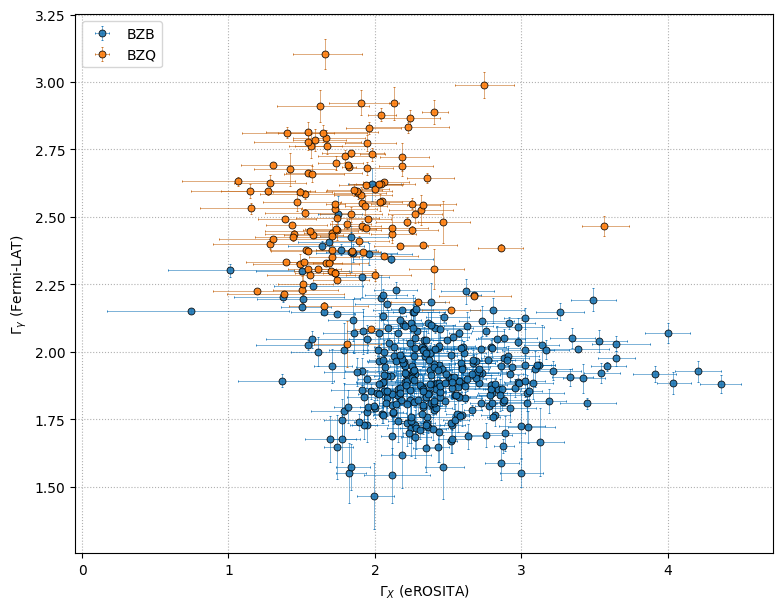

In [31]:
plt.figure(figsize = (9,7))
#BZB
x1 = np.array(df_1['FREE_GAMMA'], dtype=float)
y1 = np.array(df_1['FGL_PL_INDEX'], dtype=float)
x1_err_raw = np.vstack(df_1['FREE_GAMMA_ERR'].values)
x1_err = [np.abs(x1_err_raw[:, 0]) / df_1['FREE_GAMMA'].values, np.abs(x1_err_raw[:, 1]) / df_1['FREE_GAMMA'].values] #Esto toma en cuenta los errores simétricos

y1_err = np.abs(df_1['FGL_PL_INDEX_ERR']/df_1['FGL_PL_INDEX']).values

plt.errorbar( x1, y1, 
    xerr=x1_err, 
    yerr=y1_err,
    fmt='o',
    color='#1f77b4', 
    alpha=0.9, 
    ecolor="#0068b2af",   
    elinewidth=0.4, 
    capsize=1,  
    mec='k', 
    mew=0.6, 
    ms=5, 
    label='BZB'
)

# BZQ
x2 = np.array(df_2['FREE_GAMMA'], dtype=float)
y2 = np.array(df_2['FGL_PL_INDEX'], dtype=float)

x2_err_raw = np.vstack(df_2['FREE_GAMMA_ERR'].values)
x2_err = [np.abs(x2_err_raw[:, 0]) / df_2['FREE_GAMMA'].values, np.abs(x2_err_raw[:, 1]) / df_2['FREE_GAMMA'].values] #Esto toma en cuenta los errores simétricos

y2_err = np.abs(df_2['FGL_PL_INDEX_ERR']/df_2['FGL_PL_INDEX']).values
plt.errorbar(
    x2, y2, 
    xerr=x2_err, 
    yerr=y2_err,
    fmt='o',
    color='#ff7f0e', 
    alpha=0.9, 
    ecolor="#c15a00b6",
    elinewidth=0.4, 
    capsize=1,  
    mec='k', 
    mew=0.6, 
    ms=5, 
    label='BZQ'
)

#plt.title('Dispersión de blázares')
plt.xlabel(r'$\Gamma_X$ (eROSITA)')
plt.ylabel(r'$\Gamma_\gamma$ (Fermi-LAT)')
plt.legend(loc='upper left')
plt.grid(True, linestyle=':')
plt.savefig('BZscat.pdf')
plt.show()

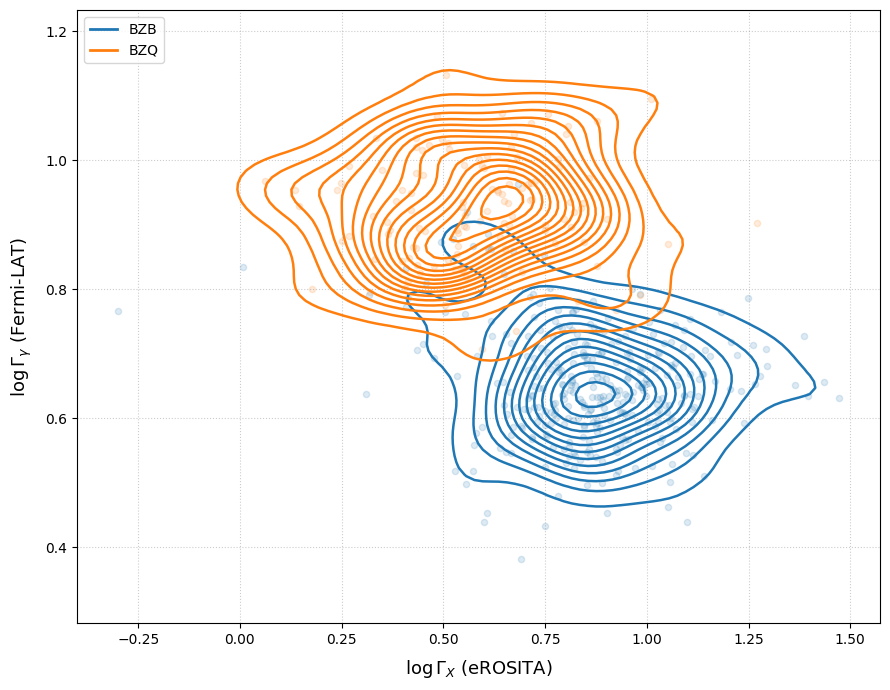

In [33]:
import matplotlib.lines as mlines
#BZB
valid_bzb = df_1['FREE_GAMMA'].notna() & df_1['FGL_PL_INDEX'].notna()
x_bzb = np.log(df_1.loc[valid_bzb, 'FREE_GAMMA']).values
y_bzb = np.log(df_1.loc[valid_bzb, 'FGL_PL_INDEX']).values

#BZQ
valid_bzq = df_2['FREE_GAMMA'].notna() & df_2['FGL_PL_INDEX'].notna()
x_bzq = np.log(df_2.loc[valid_bzq, 'FREE_GAMMA']).values
y_bzq = np.log(df_2.loc[valid_bzq, 'FGL_PL_INDEX']).values

xmin = min(x_bzb.min(), x_bzq.min()) - 0.1
xmax = max(x_bzb.max(), x_bzq.max()) + 0.1
ymin = min(y_bzb.min(), y_bzq.min()) - 0.1
ymax = max(y_bzb.max(), y_bzq.max()) + 0.1

X, Y = np.meshgrid(np.linspace(xmin, xmax, 100), np.linspace(ymin, ymax, 100))
posiciones = np.vstack([X.ravel(), Y.ravel()])


kernel_bzb = gaussian_kde(np.vstack([x_bzb, y_bzb]))
Z_bzb = np.reshape(kernel_bzb(posiciones).T, X.shape)

kernel_bzq = gaussian_kde(np.vstack([x_bzq, y_bzq]))
Z_bzq = np.reshape(kernel_bzq(posiciones).T, X.shape)

fig, ax = plt.subplots(figsize=(9, 7))

ax.scatter(x_bzb, y_bzb, color='#1f77b4', alpha=0.15, s=20)
ax.scatter(x_bzq, y_bzq, color='#ff7f0e', alpha=0.15, s=20)

ax.contour(X, Y, Z_bzb, levels=17, colors='#1f77b4', linewidths=1.8)
ax.contour(X, Y, Z_bzq, levels=17, colors='#ff7f0e', linewidths=1.8)

# 7. Formato y Leyendas
#ax.set_title('Curvas de dispersión de los blázares')
ax.set_xlabel(r'$\log \Gamma_X$ (eROSITA)', fontsize=13, labelpad=8)
ax.set_ylabel(r'$\log \Gamma_\gamma$ (Fermi-LAT)', fontsize=13, labelpad=8)

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
ax.grid(True, linestyle=':', alpha=0.4, color='gray')

# Truco para la leyenda: crear líneas proxy para representar los contornos
linea_bzb = mlines.Line2D([], [], color='#1f77b4', lw=2, label='BZB')
linea_bzq = mlines.Line2D([], [], color='#ff7f0e', lw=2, label='BZQ')
ax.legend(handles=[linea_bzb, linea_bzq], loc='upper left')

plt.tight_layout()
plt.savefig('BZCont.pdf')
plt.show()

El promedio del índice fotónico de rayos X en BZQ es 1.826 y en BZB es 2.423


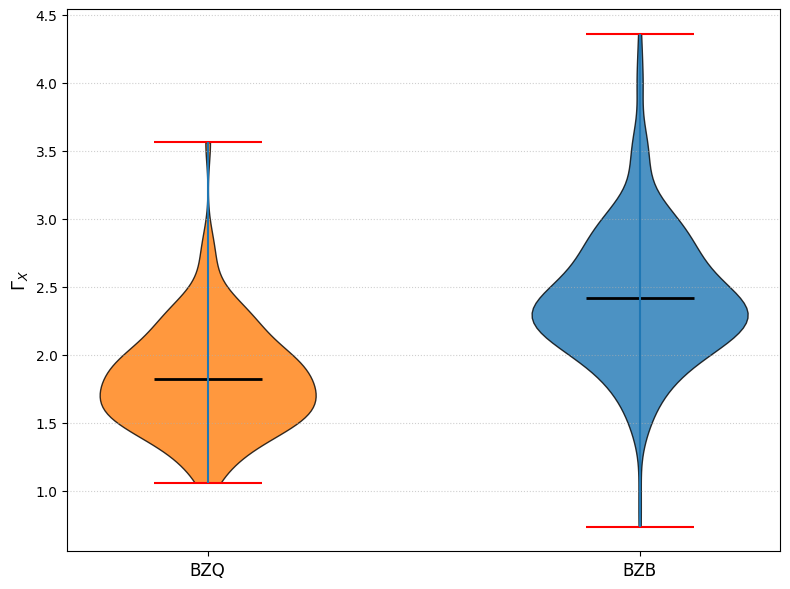

In [38]:
datos = [df_2['FREE_GAMMA'].values, df_1['FREE_GAMMA'].values]

fig, ax = plt.subplots(figsize=(8, 6))
partes = ax.violinplot(datos, showmeans=True, showmedians=False, showextrema=True)


colores = ['#ff7f0e', '#1f77b4']  # BZQ, BZB

for pc, color in zip(partes['bodies'], colores):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.8)

partes['cmaxes'].set_edgecolor('red')
partes['cmins'].set_edgecolor('red')
partes['cmeans'].set_edgecolor('black')
partes['cmeans'].set_linewidth(2)

#ax.set_title('Distribución espectral por blázar (eROSITA)', fontsize=15, pad=15)
ax.set_ylabel(r'$\Gamma_{X}$', fontsize=13)

ax.set_xticks([1, 2])
ax.set_xticklabels(['BZQ', 'BZB'], fontsize=12)

ax.yaxis.grid(True, linestyle=':', alpha=0.6)

print(f'El promedio del índice fotónico de rayos X en BZQ es {np.mean(datos[0]):.3f} y en BZB es {np.mean(datos[1]):.3f}')

plt.tight_layout()
plt.savefig('EROSITAVIOL.pdf')
plt.show()

El promedio del índice fotónico de rayos gamma en BZQ es 2.527 y en BZB es 1.925


<>:19: SyntaxWarning: invalid escape sequence '\G'
<>:19: SyntaxWarning: invalid escape sequence '\G'
C:\Users\jaosi\AppData\Local\Temp\ipykernel_14508\1723830066.py:19: SyntaxWarning: invalid escape sequence '\G'
  ax.set_ylabel('$\Gamma_\gamma$', fontsize=13)


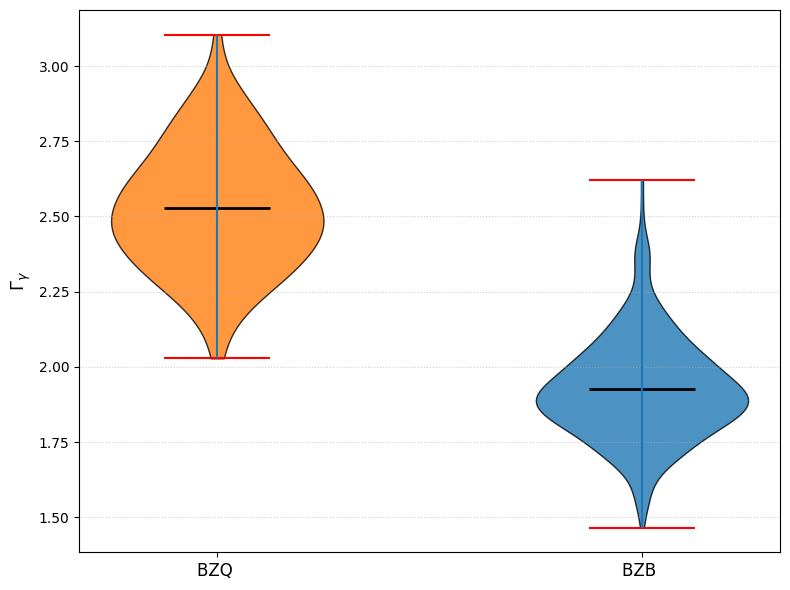

In [40]:
datos2 = [ df_2['FGL_PL_INDEX'].values, df_1['FGL_PL_INDEX'].values]
fig, ax = plt.subplots(figsize=(8, 6))
partes = ax.violinplot(datos2, showmeans=True, showmedians=False, showextrema=True)

colores = ['#ff7f0e', '#1f77b4']  # BZQ, BZB

for pc, color in zip(partes['bodies'], colores):
    pc.set_facecolor(color)
    pc.set_edgecolor('black')
    pc.set_alpha(0.8)

partes['cmaxes'].set_edgecolor('red')     # Línea del valor máximo en rojo
partes['cmins'].set_edgecolor('red')     # Línea del valor mínimo en rojo
partes['cmeans'].set_edgecolor('black')   # Línea de la media en negro
partes['cmeans'].set_linewidth(2)


#ax.set_title('Distribución espectral por blázar (Fermi-LAT)', fontsize=15, pad=15)
ax.set_ylabel('$\Gamma_\gamma$', fontsize=13)

ax.set_xticks([1, 2])
ax.set_xticklabels(['BZQ ', 'BZB '], fontsize=12)

ax.yaxis.grid(True, linestyle=':', alpha=0.6)
print(f'El promedio del índice fotónico de rayos gamma en BZQ es {np.mean(datos2[0]):.3f} y en BZB es {np.mean(datos2[1]):.3f}')
plt.tight_layout()
plt.savefig('FERMIVIOL.pdf')
plt.show()

### Prueba KS

In [ ]:
import scipy.stats as stats #La hipótesis nula es la 
statistic1, p_value1 = stats.kstest(df_1['FREE_GAMMA'],df_2['FREE_GAMMA'])
statistic2, p_value2 = stats.kstest(df_1['FGL_PL_INDEX'],df_2['FGL_PL_INDEX'])
print('eROSITA presenta un KS statistic de',statistic1,'y un P value de ', p_value1)
print('Fermi-LAT presenta un KS statistic de',statistic2,'y un P value de ', p_value2)

eROSITA presenta un KS statistic de 0.5972891566265061 y un P value de  5.830214262891178e-30
Fermi-LAT presenta un KS statistic de 0.9041164658634538 y un P value de  4.816102217741182e-79
